In [1]:
import pandas as pd

In [2]:
df = pd.read_csv ("patient_churn_dataset.csv")

#### Overall Churn Rate

In [3]:
# Total patients
total_patients = len(df)

# Total churned
churned = df["Churned"].sum()

# Churn rate
churn_rate = (churned / total_patients) * 100

print("Total Patients:", total_patients)
print("Total Churned:", churned)
print("Churn Rate: {:.2f}%".format(churn_rate))

Total Patients: 2000
Total Churned: 1367
Churn Rate: 68.35%


#### Compare Averages (Churned vs Retained)

In [4]:
df.groupby("Churned")[[
    "Tenure_Months",
    "Visits_Last_Year",
    "Missed_Appointments",
    "Days_Since_Last_Visit",
    "Avg_Out_Of_Pocket_Cost",
    "Overall_Satisfaction"
]].mean()

,Tenure_Months,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,Avg_Out_Of_Pocket_Cost,Overall_Satisfaction
Churned,,,,,,
0,64.846761,7.259084,1.854660,339.140600,787.734597,3.483096
1,58.828822,7.778347,2.108266,378.627652,859.145574,3.149378


#### Which Insurance Type Has Highest Churn?

In [5]:
df.groupby("Insurance_Type")["Churned"].mean().sort_values(ascending=False)

Insurance_Type
Medicaid    0.705021
Private     0.693582
Self-Pay    0.671128
Medicare    0.666667
Name: Churned, dtype: float64

In [6]:
df.shape

(2000, 21)

#### which specialty is losing the most patients.

In [7]:
df.groupby("Specialty")["Churned"].mean().sort_values(ascending=False)

Specialty
Neurology            0.702797
Family Medicine      0.702422
Pediatrics           0.697183
General Practice     0.695364
Internal Medicine    0.693141
Cardiology           0.652015
Orthopedics          0.640138
Name: Churned, dtype: float64

#### Root Cause

In [8]:
df.groupby("Portal_Usage")["Churned"].mean()

Portal_Usage
0    0.700882
1    0.616505
Name: Churned, dtype: float64

#### Do billing problems increase churn?

In [9]:
df.groupby("Billing_Issues")["Churned"].mean()

Billing_Issues
0    0.676072
1    0.770701
Name: Churned, dtype: float64

In [10]:
df.groupby(["Billing_Issues", "Portal_Usage"])["Churned"].mean()

Billing_Issues  Portal_Usage
0               0               0.694787
                1               0.605195
1               0               0.769231
                1               0.777778
Name: Churned, dtype: float64

In [11]:
import numpy as np

# Create risk score column
df["Risk_Score"] = 0

# Billing issues = +25 points
df.loc[df["Billing_Issues"] == 1, "Risk_Score"] += 25

# No portal usage = +15 points
df.loc[df["Portal_Usage"] == 0, "Risk_Score"] += 15

# Low satisfaction (<3) = +15 points
df.loc[df["Overall_Satisfaction"] < 3, "Risk_Score"] += 15

# Long gap since visit (>365 days) = +20 points
df.loc[df["Days_Since_Last_Visit"] > 365, "Risk_Score"] += 20

# High missed appointments (>3) = +10 points
df.loc[df["Missed_Appointments"] > 3, "Risk_Score"] += 10

# High cost (>800) = +15 points
df.loc[df["Avg_Out_Of_Pocket_Cost"] > 800, "Risk_Score"] += 15

df.head()

,PatientID,Age,Gender,State,Tenure_Months,Specialty,Insurance_Type,Visits_Last_Year,Missed_Appointments,Days_Since_Last_Visit,...,Wait_Time_Satisfaction,Staff_Satisfaction,Provider_Rating,Avg_Out_Of_Pocket_Cost,Billing_Issues,Portal_Usage,Referrals_Made,Distance_To_Facility_Miles,Churned,Risk_Score
0,C20000,41,Female,PA,62,Pediatrics,Medicaid,1,0,564,...,4.9,3.8,4.2,306,0,0,3,21.4,1,35
1,C20001,43,Female,GA,44,Internal Medicine,Self-Pay,7,4,254,...,3.1,4.7,4.3,1851,0,0,0,47.6,1,55
2,C20002,21,Male,MI,120,Internal Medicine,Medicaid,15,5,89,...,4.4,2.1,4.7,391,0,0,2,7.1,0,40
3,C20003,65,Male,FL,118,General Practice,Private,10,3,135,...,4.3,4.3,4.9,808,0,0,0,11.6,1,45
4,C20004,18,Female,CA,70,Cardiology,Medicaid,5,4,696,...,4.0,4.1,4.4,866,0,0,0,10.3,1,75


In [12]:
df["Risk_Level"] = pd.cut(
    df["Risk_Score"],
    bins=[-1, 30, 60, 100],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

df[["Risk_Score", "Risk_Level"]].head()

,Risk_Score,Risk_Level
0,35,Medium Risk
1,55,Medium Risk
2,40,Medium Risk
3,45,Medium Risk
4,75,High Risk


In [13]:
df.groupby("Risk_Level")["Churned"].mean()

C:\Users\USER\AppData\Local\Temp\ipykernel_23216\3946600180.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Risk_Level")["Churned"].mean()


Risk_Level
Low Risk       0.590489
Medium Risk    0.721731
High Risk      0.823009
Name: Churned, dtype: float64

In [14]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [15]:
features = [
    "Billing_Issues",
    "Portal_Usage",
    "Overall_Satisfaction",
    "Days_Since_Last_Visit",
    "Missed_Appointments",
    "Avg_Out_Of_Pocket_Cost",
    "Tenure_Months"
]

X = df[features]
y = df["Churned"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [17]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [18]:
y_pred = model.predict(X_test)

In [19]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.71

Confusion Matrix:
 [[ 12 157]
 [ 17 414]]

Classification Report:
               precision    recall  f1-score   support

           0       0.41      0.07      0.12       169
           1       0.73      0.96      0.83       431

    accuracy                           0.71       600
   macro avg       0.57      0.52      0.47       600
weighted avg       0.64      0.71      0.63       600



## importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
})

importance.sort_values(by="Coefficient", ascending=False)

In [20]:
importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
})

importance = importance.sort_values(by="Coefficient", ascending=False)
importance

,Feature,Coefficient
0,Billing_Issues,0.435436
4,Missed_Appointments,0.088670
3,Days_Since_Last_Visit,0.000732
5,Avg_Out_Of_Pocket_Cost,0.000288
6,Tenure_Months,-0.006196
2,Overall_Satisfaction,-0.281845
1,Portal_Usage,-0.369914


In [21]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [22]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.6233333333333333

Confusion Matrix:
 [[103  66]
 [160 271]]

Classification Report:
               precision    recall  f1-score   support

           0       0.39      0.61      0.48       169
           1       0.80      0.63      0.71       431

    accuracy                           0.62       600
   macro avg       0.60      0.62      0.59       600
weighted avg       0.69      0.62      0.64       600



In [23]:
y_probs = model.predict_proba(X_test)[:, 1]

In [24]:
import numpy as np

threshold = 0.6
y_pred_custom = np.where(y_probs > threshold, 1, 0)

print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

[[146  23]
 [306 125]]
              precision    recall  f1-score   support

           0       0.32      0.86      0.47       169
           1       0.84      0.29      0.43       431

    accuracy                           0.45       600
   macro avg       0.58      0.58      0.45       600
weighted avg       0.70      0.45      0.44       600



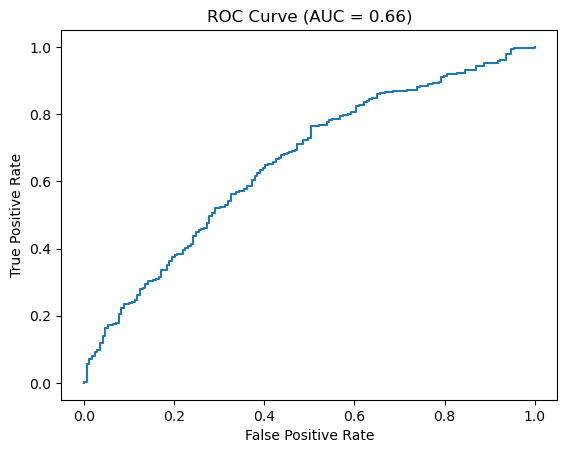

AUC Score: 0.6567223602740291


In [25]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc_score:.2f})")
plt.show()

print("AUC Score:", auc_score)

In [26]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

feature_importance['Absolute'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Absolute', ascending=False)

feature_importance.head(10)

,Feature,Coefficient,Absolute
0,Billing_Issues,0.470114,0.470114
1,Portal_Usage,-0.364685,0.364685
2,Overall_Satisfaction,-0.283522,0.283522
4,Missed_Appointments,0.092244,0.092244
6,Tenure_Months,-0.006137,0.006137
3,Days_Since_Last_Visit,0.000716,0.000716
5,Avg_Out_Of_Pocket_Cost,0.000295,0.000295


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nAUC Score:", roc_auc_score(y_test, y_probs_rf))

Accuracy: 0.7166666666666667

Confusion Matrix:
 [[ 26 143]
 [ 27 404]]

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.15      0.23       169
           1       0.74      0.94      0.83       431

    accuracy                           0.72       600
   macro avg       0.61      0.55      0.53       600
weighted avg       0.67      0.72      0.66       600


AUC Score: 0.5927113222312221


In [28]:
# Predict probabilities
y_probs = model.predict_proba(X_test)[:, 1]

# Predict classes
y_pred = model.predict(X_test)

In [29]:
import pandas as pd
import numpy as np

# Create export dataframe
export_df = X_test.copy()

export_df['Actual_Churn'] = y_test.values
export_df['Predicted_Churn'] = y_pred
export_df['Churn_Probability'] = y_probs

# Create Risk Level
export_df['Risk_Level'] = np.where(
    export_df['Churn_Probability'] >= 0.7, "High Risk",
    np.where(export_df['Churn_Probability'] >= 0.4, "Medium Risk", "Low Risk")
)

export_df.head()

,Billing_Issues,Portal_Usage,Overall_Satisfaction,Days_Since_Last_Visit,Missed_Appointments,Avg_Out_Of_Pocket_Cost,Tenure_Months,Actual_Churn,Predicted_Churn,Churn_Probability,Risk_Level
1860,0,0,4.6,332,3,1899,29,0,1,0.569717,Medium Risk
353,0,0,2.5,343,2,1313,44,1,1,0.628688,Medium Risk
1333,0,1,1.7,232,2,1451,41,0,1,0.591086,Medium Risk
905,0,1,2.0,557,3,75,43,1,1,0.547246,Medium Risk
1289,0,0,4.5,668,3,754,31,0,1,0.549599,Medium Risk


In [30]:
export_df.to_csv("patient_churn_predictions.csv", index=False)

In [33]:
# Predict churn (0 or 1)
y_pred = model.predict(X_test)

# Predict churn probability
y_prob = model.predict_proba(X_test)[:,1]

# Create predictions table
predictions = pd.DataFrame({
    'PatientID': df.loc[X_test.index, 'PatientID'],
    'Predicted_Churn': y_pred,
    'Churn_Probability': y_prob
})


In [34]:
# Export to CSV
predictions.to_csv('Patient_churn_predictions.csv', index=False)